In [1]:
# ============================================================
# Cell 1 | 盲测小黑屋:只用早期数据(SOH≥90%)预测,存Prediction_xxx.csv
# 严格隔离:绝不读后期真实容量
# ============================================================
import s3fs, re, numpy as np, pandas as pd, torch, torch.nn as nn, joblib, warnings
import scipy.integrate as integrate
warnings.filterwarnings("ignore")
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

TARGET_BATTERY = "020"        # ← 改电池编号
LATE_SOH = 90.0               # 早期边界:只用SOH≥90%的checkup
EOL = 0.88; MAX_EFC = 15000   # EOL阈值 + 横轴铺多远

print(f"▶️ [Cell 1 | 盲测小黑屋] 电池 {TARGET_BATTERY} 凭早期数据预测...")

OPTS = {"key": S3_ACCESS_KEY, "secret": S3_SECRET_KEY,
        "client_kwargs": {"endpoint_url": "https://iseadocker.isea.rwth-aachen.de:9000", "region_name": "us-east-1"},
        "config_kwargs": {"s3": {"addressing_style": "path"}, "signature_version": "s3v4"}}
QOCV="projects/j8005-metabatt/Metabatt/A123/30_export_qocv"
PULSE="projects/j8005-metabatt/Metabatt/A123/20_export_pulse"
NOMINAL=1.1; V_GRID=np.linspace(2.2,3.45,200)
feat_cols=['F1_CC_time_diff','F7_IC_area_diff','F8_discharge_time_diff','F9_var_dTV',
           'F17_mean_dQV','F22_linear_intercept','F24_sqrt_intercept','F34_temp_integral_diff',
           'F35_min_temp_diff','F38_mean_min_temp','F39_mean_avg_temp','F41_IR_diff',
           'cond_temp','cond_soc','cond_dod','cond_crate']

# 17维DNN(与训练一致)
class TrajectoryDNN(nn.Module):
    def __init__(self,d=17):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,64),nn.ReLU(),nn.Dropout(0.1),
                               nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1))
    def forward(self,x): return self.net(x)

scaler=joblib.load('traj_scaler.pkl'); svr=joblib.load('traj_svr.pkl')
dnn=TrajectoryDNN(17); dnn.load_state_dict(torch.load('traj_dnn.pth')); dnn.eval()

fs=s3fs.S3FileSystem(**OPTS)
bid=TARGET_BATTERY.zfill(3)
cond=pd.read_csv("battery_conditions.csv",dtype={'bid':str}).set_index('bid').loc[bid]

# ---- 只读SOH≥90%的早期anchor提取16维特征 ----
qf=fs.ls(f"{QOCV}/METABatt_A123_APR18650M1B_{bid}")
def parse(f):
    m=re.search(r'_([\d.]+)SOH',f.split('/')[-1]); b=re.search(r'BM(\d+)',f)
    return (f,int(b.group(1)) if b else -1,float(m.group(1)) if m else None)
dch=[parse(f) for f in qf if 'dch' in f.lower()]; dch=[x for x in dch if x[2] is not None]
cha=[parse(f) for f in qf if 'cha' in f.lower()]; cha=[x for x in cha if x[2] is not None]
dch_e=[x for x in dch if x[2]>=LATE_SOH]
if len(dch_e)<2: dch_e=sorted(dch,key=lambda x:-x[2])[:2]
dch_e.sort(key=lambda x:-x[2])
early=dch_e[0]; late=min(dch_e,key=lambda x:abs(x[2]-LATE_SOH))
if late[0]==early[0]: late=dch_e[1]
cha_map={b:f for f,b,s in cha}
def rd(p,c): return pd.read_parquet(f"s3://{p}",columns=c,storage_options=OPTS)
de=rd(early[0],['Voltage','Ah_throughput','Temperature','Time'])
dl=rd(late[0],['Voltage','Ah_throughput','Temperature','Time'])
for d in (de,dl):
    d['Q']=d['Ah_throughput']-d['Ah_throughput'].iloc[0]
    d['t']=(pd.to_datetime(d['Time'])-pd.to_datetime(d['Time']).iloc[0]).dt.total_seconds()
def og(d,c):
    v=d['Voltage'].values;y=d[c].values;o=np.argsort(v);vu,i=np.unique(v[o],return_index=True)
    return np.interp(V_GRID,vu,y[o][i],left=np.nan,right=np.nan)
dQ=og(dl,'Q')-og(de,'Q'); dT=og(dl,'t')-og(de,'t'); dQ=dQ[~np.isnan(dQ)]; dT=dT[~np.isnan(dT)]
def ic(d):
    Q=d['Q'].values;V=d['Voltage'].values;o=np.argsort(V);Vu,i=np.unique(V[o],return_index=True)
    return float(np.trapz(np.gradient(Q[o][i],Vu),Vu))
def ccd(b):
    if b not in cha_map: return np.nan
    c=rd(cha_map[b],['Voltage','Time']);cc=c[c['Voltage']<3.59]
    if len(cc)<2: return np.nan
    return float((pd.to_datetime(cc['Time'])-pd.to_datetime(cc['Time']).iloc[0]).dt.total_seconds().iloc[-1])
def dcir(b):
    try: pf=[f for f in fs.ls(f"{PULSE}/METABatt_A123_APR18650M1B_{bid}") if f'BM{b}_' in f]
    except: return np.nan
    if not pf: return np.nan
    p=rd(pf[0],['Current','Voltage']);dI=p['Current'].diff();dV=p['Voltage'].diff();k=dI.abs().idxmax()
    return float(abs(dV[k]/dI[k])) if abs(dI[k])>0.5 else np.nan
pts=sorted([(rd(x[0],['Ah_throughput'])['Ah_throughput'].iloc[0]/NOMINAL, x[2]/100*NOMINAL) for x in dch_e])
x=np.array([p[0] for p in pts]); y=np.array([p[1] for p in pts])
p2=np.polyfit(x,y,1)[1] if len(x)>=2 else y[0]
p4=np.linalg.lstsq(np.c_[np.sqrt(np.maximum(x,1e-9)),np.ones_like(x)],y,rcond=None)[0][1] if len(x)>=2 else y[0]
der,dlr=dcir(early[1]),dcir(late[1])
feats={'F1_CC_time_diff':(ccd(late[1])-ccd(early[1])) if(early[1] in cha_map and late[1] in cha_map) else 0.0,
   'F7_IC_area_diff':ic(dl)-ic(de),'F8_discharge_time_diff':float(dl['t'].iloc[-1]-de['t'].iloc[-1]),
   'F9_var_dTV':float(np.var(dT)) if len(dT) else 0.0,'F17_mean_dQV':float(np.mean(dQ)) if len(dQ) else 0.0,
   'F22_linear_intercept':float(p2),'F24_sqrt_intercept':float(p4),
   'F34_temp_integral_diff':float(integrate.trapezoid(dl['Temperature'],dl['t'])-integrate.trapezoid(de['Temperature'],de['t'])),
   'F35_min_temp_diff':float(dl['Temperature'].min()-de['Temperature'].min()),
   'F38_mean_min_temp':float(de['Temperature'].min()),'F39_mean_avg_temp':float(de['Temperature'].mean()),
   'F41_IR_diff':float(dlr-der) if not(np.isnan(der) or np.isnan(dlr)) else 0.0,
   'cond_temp':cond['temp'],'cond_soc':cond['soc'],'cond_dod':cond['dod'],'cond_crate':cond['crate']}
f16=np.array([feats[c] for c in feat_cols],dtype=float)
print(f"  早期特征提取完成(仅用SOH≥{LATE_SOH}%: {early[2]:.1f}%→{late[2]:.1f}%)")

# ---- 横轴铺远,预测整条曲线 ----
dense=np.linspace(300,MAX_EFC,400)
Xq=scaler.transform([np.append(f16,e) for e in dense])
svr_c=svr.predict(Xq)
with torch.no_grad(): dnn_c=dnn(torch.tensor(Xq,dtype=torch.float32)).numpy().flatten()

# ---- 存预测文件(隔离:只有预测,无真实值) ----
pd.DataFrame({'EFC':dense,'SVR_Capacity':svr_c,'DNN_Capacity':dnn_c}).to_csv(f"Prediction_{TARGET_BATTERY}.csv",index=False)
print(f"✅ 预测已存 Prediction_{TARGET_BATTERY}.csv (绝无真实值泄漏)")

▶️ [Cell 1 | 盲测小黑屋] 电池 020 凭早期数据预测...
  早期特征提取完成(仅用SOH≥90.0%: 100.5%→90.3%)
✅ 预测已存 Prediction_020.csv (绝无真实值泄漏)


In [4]:
# ============================================================
# Cell 2 | 官方阅卷室:独立提取真实容量轨迹,存GroundTruth_xxx.csv
# 与Cell1完全独立,只读真实SOH(文件名),不碰模型
# ============================================================
import s3fs, re, numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

TARGET_BATTERY = "020"        # ← 改成和Cell1相同的编号
NOMINAL = 1.1

print(f"▶️ [Cell 2 | 官方阅卷室] 提取电池 {TARGET_BATTERY} 的真实轨迹...")

OPTS = {"key": S3_ACCESS_KEY, "secret": S3_SECRET_KEY,
        "client_kwargs": {"endpoint_url": "https://iseadocker.isea.rwth-aachen.de:9000", "region_name": "us-east-1"},
        "config_kwargs": {"s3": {"addressing_style": "path"}, "signature_version": "s3v4"}}
QOCV="projects/j8005-metabatt/Metabatt/A123/30_export_qocv"

fs=s3fs.S3FileSystem(**OPTS)
bid=TARGET_BATTERY.zfill(3)

# 读全部dch文件名 → (EFC, 真实容量)。EFC用Ah_throughput,容量用SOH×标称
rows=[]
for f in fs.ls(f"{QOCV}/METABatt_A123_APR18650M1B_{bid}"):
    if 'dch' not in f.lower(): continue
    m=re.search(r'_([\d.]+)SOH',f.split('/')[-1])
    if m is None: continue                       # 跳过NASOH
    soh=float(m.group(1))
    thr=pd.read_parquet(f"s3://{f}",columns=['Ah_throughput'],storage_options=OPTS)['Ah_throughput'].iloc[0]
    rows.append({'EFC':thr/NOMINAL,'True_Capacity':soh/100*NOMINAL,'SOH':soh})
gt=pd.DataFrame(rows).sort_values('EFC').reset_index(drop=True)
gt.to_csv(f"GroundTruth_{TARGET_BATTERY}.csv",index=False)
print(f"✅ 真实轨迹已存 GroundTruth_{TARGET_BATTERY}.csv ({len(gt)}个点, EFC {gt.EFC.min():.0f}~{gt.EFC.max():.0f})")

▶️ [Cell 2 | 官方阅卷室] 提取电池 020 的真实轨迹...
✅ 真实轨迹已存 GroundTruth_020.csv (22个点, EFC 544~10050)


▶️ [Cell 3 | 终极对账所] 电池 020 隔离对账...

🏆 电池 [020] 物理隔离闭环验证
   [SVR] 容量RMSE: 0.0105 Ah | MAPE: 0.76%
   [DNN] 容量RMSE: 0.0215 Ah | MAPE: 1.54%
------------------------------------------------------------------
   寿命(EFC到80%SOH):  真实=>范围  SVR=13231  DNN=9071


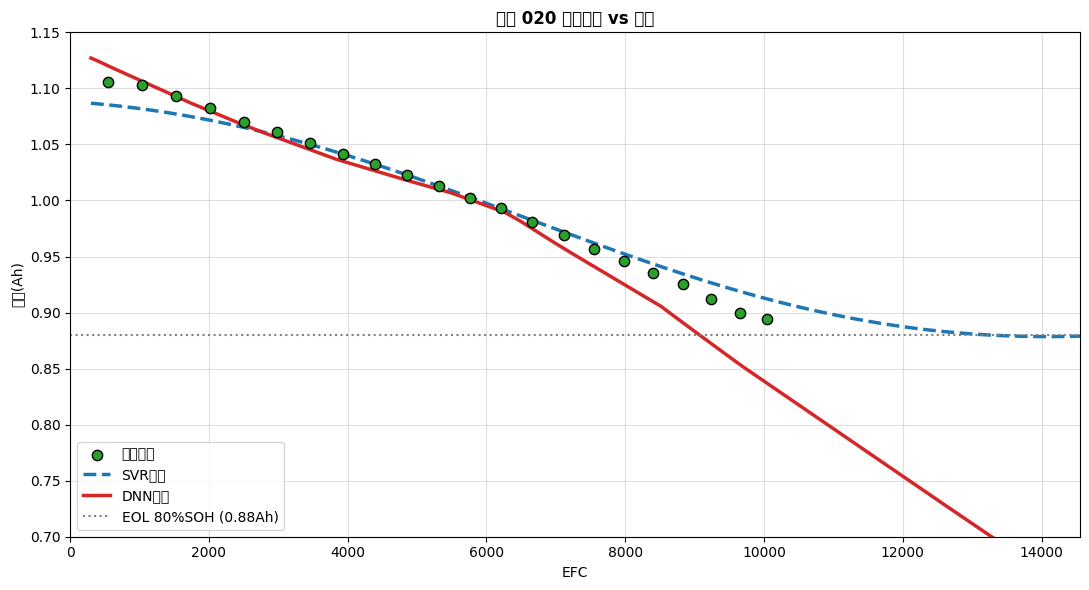

In [6]:
# ============================================================
# Cell 3 | 终极对账所:读两个隔离文件对比,算误差+预测寿命
# ============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

TARGET_BATTERY = "020"        # ← 改成和Cell1/2相同的编号
EOL = 0.88                    # 80%SOH × 1.1标称

print(f"▶️ [Cell 3 | 终极对账所] 电池 {TARGET_BATTERY} 隔离对账...\n")

df_pred=pd.read_csv(f"Prediction_{TARGET_BATTERY}.csv")
df_gt  =pd.read_csv(f"GroundTruth_{TARGET_BATTERY}.csv")

true_efc=df_gt['EFC'].values; true_cap=df_gt['True_Capacity'].values
de=df_pred['EFC'].values; svr_c=df_pred['SVR_Capacity'].values; dnn_c=df_pred['DNN_Capacity'].values

# 在真实EFC点上插值取预测值,算误差(不泄漏:预测曲线早已独立生成)
ev_svr=np.interp(true_efc,de,svr_c); ev_dnn=np.interp(true_efc,de,dnn_c)
rmse_svr=np.sqrt(mean_squared_error(true_cap,ev_svr)); mape_svr=mean_absolute_percentage_error(true_cap,ev_svr)*100
rmse_dnn=np.sqrt(mean_squared_error(true_cap,ev_dnn)); mape_dnn=mean_absolute_percentage_error(true_cap,ev_dnn)*100

# 寿命对比:各曲线穿过EOL的EFC
def life(efc,cap,thr):
    b=np.where(cap<thr)[0]
    if len(b)==0: return None
    i=b[0]
    if i==0: return float(efc[0])
    return float(efc[i-1]+(thr-cap[i-1])*(efc[i]-efc[i-1])/(cap[i]-cap[i-1]))
L_true=life(true_efc,true_cap,EOL); L_svr=life(de,svr_c,EOL); L_dnn=life(de,dnn_c,EOL)

print("="*66)
print(f"🏆 电池 [{TARGET_BATTERY}] 物理隔离闭环验证")
print("="*66)
print(f"   [SVR] 容量RMSE: {rmse_svr:.4f} Ah | MAPE: {mape_svr:.2f}%")
print(f"   [DNN] 容量RMSE: {rmse_dnn:.4f} Ah | MAPE: {mape_dnn:.2f}%")
print("-"*66)
fmt=lambda v:f"{v:.0f}" if v else ">范围"
print(f"   寿命(EFC到80%SOH):  真实={fmt(L_true)}  SVR={fmt(L_svr)}  DNN={fmt(L_dnn)}")
if L_true and L_svr: print(f"   SVR寿命误差: {abs(L_svr-L_true):.0f} EFC")
if L_true and L_dnn: print(f"   DNN寿命误差: {abs(L_dnn-L_true):.0f} EFC")
print("="*66)

# 画图:真实散点 + 两条预测曲线
plt.figure(figsize=(11,6))
plt.scatter(true_efc,true_cap,c='#2ca02c',s=55,edgecolor='k',label='真实容量',zorder=5)
plt.plot(de,svr_c,'--',c='#1f77b4',lw=2.5,label='SVR预测')
plt.plot(de,dnn_c,'-',c='#d62728',lw=2.5,label='DNN预测')
plt.axhline(EOL,color='gray',ls=':',label=f'EOL 80%SOH ({EOL}Ah)')
plt.xlim(0,max(true_efc.max(),de[np.where(svr_c<EOL)[0][0]] if (svr_c<EOL).any() else de.max())*1.1)
plt.ylim(0.7,1.15)
plt.title(f"电池 {TARGET_BATTERY} 早期预测 vs 真实",fontweight='bold')
plt.xlabel("EFC"); plt.ylabel("容量(Ah)"); plt.legend(loc='lower left'); plt.grid(alpha=.4)
plt.tight_layout(); plt.show()